In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import faiss
import time
import os
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
!wget --show-progress https://ann-benchmarks.com/sift-128-euclidean.hdf5

--2026-03-27 07:21:42--  https://ann-benchmarks.com/sift-128-euclidean.hdf5
Resolving ann-benchmarks.com (ann-benchmarks.com)... 172.67.134.227, 104.21.25.235, 2606:4700:3035::6815:19eb, ...
Connecting to ann-benchmarks.com (ann-benchmarks.com)|172.67.134.227|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 525128288 (501M)
Saving to: ‘sift-128-euclidean.hdf5’

sift-128-euclidean. 100%[===================>] 500.80M  11.1MB/s    in 25m 14s 

2026-03-27 07:46:57 (339 KB/s) - ‘sift-128-euclidean.hdf5’ saved [525128288/525128288]



In [ ]:
import h5py
import numpy as np

# Open the HDF5 file
f = h5py.File('sift-128-euclidean.hdf5', 'r')

# See what's inside
print("Keys in dataset:", list(f.keys()))

Keys in dataset: ['distances', 'neighbors', 'test', 'train']


In [ ]:
train_data = np.array(f['train'], dtype='float32')  # 1 million vectors
query_data = np.array(f['test'], dtype='float32')    # query vectors
ground_truth = np.array(f['neighbors'])              # correct answers

# Check the shapes
print("Training vectors shape:", train_data.shape)
print("Query vectors shape:", query_data.shape)
print("Ground truth shape:", ground_truth.shape)

# Check dimension
d = train_data.shape[1]
print(f"\nEach vector has {d} dimensions")
print(f"Total vectors in database: {train_data.shape[0]:,}")
print(f"Total query vectors: {query_data.shape[0]:,}")

Training vectors shape: (1000000, 128)
Query vectors shape: (10000, 128)
Ground truth shape: (10000, 100)

Each vector has 128 dimensions
Total vectors in database: 1,000,000
Total query vectors: 10,000


In [ ]:
# Full dataset - 1 Million vectors
data_1M = train_data

# Subset - 100K vectors
data_100K = train_data[:100000]

print(f"Dataset Size 1: {data_100K.shape[0]:,} vectors")
print(f"Dataset Size 2: {data_1M.shape[0]:,} vectors")
print(f"Each vector: {d} dimensions")

Dataset Size 1: 100,000 vectors
Dataset Size 2: 1,000,000 vectors
Each vector: 128 dimensions


In [ ]:
# Function to measure memory used by an index (in MB)
def get_memory_mb(index):
    return faiss.serialize_index(index).nbytes / (1024 * 1024)

# Function to calculate Recall@10
# Recall@10 = how many of our top-10 results match the correct answers
def calculate_recall(indices, ground_truth, k=10):
    recall_scores = []
    for i in range(len(indices)):
        predicted = set(indices[i][:k])          # our top-k results
        actual = set(ground_truth[i][:k])         # correct top-k results
        overlap = len(predicted & actual)         # how many match
        recall_scores.append(overlap / k)         # score between 0 and 1
    return np.mean(recall_scores)                 # average across all queries

# Function to run search queries and measure time
def run_search(index, query_vectors, k=10):
    num_queries = len(query_vectors)
    query_times = []

    for i in range(num_queries):
        start = time.time()
        distances, indices = index.search(query_vectors[i:i+1], k)
        end = time.time()
        query_times.append((end - start) * 1000)  # convert to milliseconds

    query_times = np.array(query_times)
    all_distances, all_indices = index.search(query_vectors, k)

    return {
        'avg_time_ms': np.mean(query_times),
        'std_time_ms': np.std(query_times),
        'total_time_ms': np.sum(query_times),
        'indices': all_indices
    }

print("Helper functions ready! ✅")

Helper functions ready! ✅


In [ ]:
results = {}

print("Building 100K ground truth using FlatL2...")

# Build exact index on 100K to generate correct ground truth for 100K
index_gt = faiss.IndexFlatL2(d)
index_gt.add(data_100K)
_, ground_truth_100k = index_gt.search(query_data[:1000], 10)
print("✅ 100K ground truth ready!")

print("\n" + "=" * 50)
print("INDEX 1: IndexFlatL2 (Exact Search Baseline)")
print("=" * 50)

# --- 100K Dataset ---
print("\n📊 Testing on 100K vectors...")

index_flat_100k = faiss.IndexFlatL2(d)

start = time.time()
index_flat_100k.add(data_100K)
build_time_100k = time.time() - start

memory_100k = get_memory_mb(index_flat_100k)
print(f"✅ Built! Time: {build_time_100k:.2f}s | Memory: {memory_100k:.2f} MB")

search_results_100k = run_search(index_flat_100k, query_data[:1000], k=10)

# Use our own 100K ground truth here
recall_100k = calculate_recall(search_results_100k['indices'], ground_truth_100k, k=10)

print(f"🔍 Avg Query Time: {search_results_100k['avg_time_ms']:.4f} ms")
print(f"🎯 Recall@10: {recall_100k:.4f}")

# --- 1M Dataset ---
print("\n📊 Testing on 1M vectors...")

index_flat_1m = faiss.IndexFlatL2(d)

start = time.time()
index_flat_1m.add(data_1M)
build_time_1m = time.time() - start

memory_1m = get_memory_mb(index_flat_1m)
print(f"✅ Built! Time: {build_time_1m:.2f}s | Memory: {memory_1m:.2f} MB")

search_results_1m = run_search(index_flat_1m, query_data[:1000], k=10)

# Use original ground truth for 1M
recall_1m = calculate_recall(search_results_1m['indices'], ground_truth[:1000], k=10)

print(f"🔍 Avg Query Time: {search_results_1m['avg_time_ms']:.4f} ms")
print(f"🎯 Recall@10: {recall_1m:.4f}")

# Save results
results['FlatL2'] = {
    '100K': {'build_time': build_time_100k, 'memory': memory_100k,
             'avg_query_ms': search_results_100k['avg_time_ms'],
             'std_query_ms': search_results_100k['std_time_ms'],
             'recall': recall_100k},
    '1M':   {'build_time': build_time_1m, 'memory': memory_1m,
             'avg_query_ms': search_results_1m['avg_time_ms'],
             'std_query_ms': search_results_1m['std_time_ms'],
             'recall': recall_1m}
}

print("\n✅ FlatL2 results saved!")

Building 100K ground truth using FlatL2...
✅ 100K ground truth ready!

INDEX 1: IndexFlatL2 (Exact Search Baseline)

📊 Testing on 100K vectors...
✅ Built! Time: 0.05s | Memory: 48.83 MB
🔍 Avg Query Time: 5.4462 ms
🎯 Recall@10: 1.0000

📊 Testing on 1M vectors...
✅ Built! Time: 0.39s | Memory: 488.28 MB
🔍 Avg Query Time: 52.8391 ms
🎯 Recall@10: 0.9991

✅ FlatL2 results saved!


In [ ]:
print("=" * 50)
print("INDEX 2: IndexIVFFlat (Inverted File Index)")
print("=" * 50)

# nlist = number of clusters (cells) to divide data into
# Rule of thumb: nlist = sqrt(n) where n is dataset size
nlist = 100  # number of clusters

# --- 100K Dataset ---
print("\n📊 Testing on 100K vectors...")

# IVFFlat needs a "quantizer" - think of it as the cluster organizer
quantizer_100k = faiss.IndexFlatL2(d)
index_ivf_100k = faiss.IndexIVFFlat(quantizer_100k, d, nlist)

# IVFFlat must be TRAINED first (learns cluster centers)
start = time.time()
index_ivf_100k.train(data_100K)       # learns how to group vectors
index_ivf_100k.add(data_100K)         # adds vectors into clusters
build_time_100k = time.time() - start

memory_100k = get_memory_mb(index_ivf_100k)
print(f"✅ Built! Time: {build_time_100k:.2f}s | Memory: {memory_100k:.2f} MB")

# nprobe = how many clusters to search (higher = more accurate but slower)
index_ivf_100k.nprobe = 10

search_results_100k = run_search(index_ivf_100k, query_data[:1000], k=10)
recall_100k = calculate_recall(search_results_100k['indices'], ground_truth_100k, k=10)

print(f"🔍 Avg Query Time: {search_results_100k['avg_time_ms']:.4f} ms")
print(f"🎯 Recall@10: {recall_100k:.4f}")

# --- 1M Dataset ---
print("\n📊 Testing on 1M vectors...")

nlist_1m = 1000  # more clusters for bigger dataset

quantizer_1m = faiss.IndexFlatL2(d)
index_ivf_1m = faiss.IndexIVFFlat(quantizer_1m, d, nlist_1m)

start = time.time()
index_ivf_1m.train(data_1M)
index_ivf_1m.add(data_1M)
build_time_1m = time.time() - start

memory_1m = get_memory_mb(index_ivf_1m)
print(f"✅ Built! Time: {build_time_1m:.2f}s | Memory: {memory_1m:.2f} MB")

index_ivf_1m.nprobe = 10

search_results_1m = run_search(index_ivf_1m, query_data[:1000], k=10)
recall_1m = calculate_recall(search_results_1m['indices'], ground_truth[:1000], k=10)

print(f"🔍 Avg Query Time: {search_results_1m['avg_time_ms']:.4f} ms")
print(f"🎯 Recall@10: {recall_1m:.4f}")

# Save results
results['IVFFlat'] = {
    '100K': {'build_time': build_time_100k, 'memory': memory_100k,
             'avg_query_ms': search_results_100k['avg_time_ms'],
             'std_query_ms': search_results_100k['std_time_ms'],
             'recall': recall_100k},
    '1M':   {'build_time': build_time_1m, 'memory': memory_1m,
             'avg_query_ms': search_results_1m['avg_time_ms'],
             'std_query_ms': search_results_1m['std_time_ms'],
             'recall': recall_1m}
}

print("\n✅ IVFFlat results saved!")

INDEX 2: IndexIVFFlat (Inverted File Index)

📊 Testing on 100K vectors...
✅ Built! Time: 1.21s | Memory: 49.64 MB
🔍 Avg Query Time: 0.8421 ms
🎯 Recall@10: 0.9768

📊 Testing on 1M vectors...
✅ Built! Time: 20.79s | Memory: 496.41 MB
🔍 Avg Query Time: 0.6335 ms
🎯 Recall@10: 0.8596

✅ IVFFlat results saved!


In [ ]:
print("=" * 50)
print("INDEX 3: IndexIVFPQ (IVF + Product Quantization)")
print("=" * 50)

# PQ parameters
# m = number of sub-vectors (must divide d=128 evenly)
# bits = bits per sub-vector (8 is standard)
m = 16       # 128 / 16 = 8 → each sub-vector has 8 dimensions
bits = 8     # 8 bits per sub-vector

# --- 100K Dataset ---
print("\n📊 Testing on 100K vectors...")

nlist = 100
quantizer_100k = faiss.IndexFlatL2(d)
index_pq_100k = faiss.IndexIVFPQ(quantizer_100k, d, nlist, m, bits)

start = time.time()
index_pq_100k.train(data_100K)
index_pq_100k.add(data_100K)
build_time_100k = time.time() - start

memory_100k = get_memory_mb(index_pq_100k)
print(f"✅ Built! Time: {build_time_100k:.2f}s | Memory: {memory_100k:.2f} MB")

index_pq_100k.nprobe = 10

search_results_100k = run_search(index_pq_100k, query_data[:1000], k=10)
recall_100k = calculate_recall(search_results_100k['indices'], ground_truth_100k, k=10)

print(f"🔍 Avg Query Time: {search_results_100k['avg_time_ms']:.4f} ms")
print(f"🎯 Recall@10: {recall_100k:.4f}")

# --- 1M Dataset ---
print("\n📊 Testing on 1M vectors...")

nlist_1m = 1000
quantizer_1m = faiss.IndexFlatL2(d)
index_pq_1m = faiss.IndexIVFPQ(quantizer_1m, d, nlist_1m, m, bits)

start = time.time()
index_pq_1m.train(data_1M)
index_pq_1m.add(data_1M)
build_time_1m = time.time() - start

memory_1m = get_memory_mb(index_pq_1m)
print(f"✅ Built! Time: {build_time_1m:.2f}s | Memory: {memory_1m:.2f} MB")

index_pq_1m.nprobe = 10

search_results_1m = run_search(index_pq_1m, query_data[:1000], k=10)
recall_1m = calculate_recall(search_results_1m['indices'], ground_truth[:1000], k=10)

print(f"🔍 Avg Query Time: {search_results_1m['avg_time_ms']:.4f} ms")
print(f"🎯 Recall@10: {recall_1m:.4f}")

# Save results
results['IVFPQ'] = {
    '100K': {'build_time': build_time_100k, 'memory': memory_100k,
             'avg_query_ms': search_results_100k['avg_time_ms'],
             'std_query_ms': search_results_100k['std_time_ms'],
             'recall': recall_100k},
    '1M':   {'build_time': build_time_1m, 'memory': memory_1m,
             'avg_query_ms': search_results_1m['avg_time_ms'],
             'std_query_ms': search_results_1m['std_time_ms'],
             'recall': recall_1m}
}

print("\n✅ IVFPQ results saved!")

INDEX 3: IndexIVFPQ (IVF + Product Quantization)

📊 Testing on 100K vectors...
✅ Built! Time: 6.79s | Memory: 2.46 MB
🔍 Avg Query Time: 0.3517 ms
🎯 Recall@10: 0.6152

📊 Testing on 1M vectors...
✅ Built! Time: 29.00s | Memory: 23.51 MB
🔍 Avg Query Time: 0.3857 ms
🎯 Recall@10: 0.5386

✅ IVFPQ results saved!


In [ ]:
print("=" * 50)
print("INDEX 4: IndexHNSW (Graph-based Index)")
print("=" * 50)

# M = number of connections each vector has to neighbors
# Higher M = more accurate but more memory
M = 32

# --- 100K Dataset ---
print("\n📊 Testing on 100K vectors...")

index_hnsw_100k = faiss.IndexHNSWFlat(d, M)

start = time.time()
index_hnsw_100k.add(data_100K)
build_time_100k = time.time() - start

memory_100k = get_memory_mb(index_hnsw_100k)
print(f"✅ Built! Time: {build_time_100k:.2f}s | Memory: {memory_100k:.2f} MB")

search_results_100k = run_search(index_hnsw_100k, query_data[:1000], k=10)
recall_100k = calculate_recall(search_results_100k['indices'], ground_truth_100k, k=10)

print(f"🔍 Avg Query Time: {search_results_100k['avg_time_ms']:.4f} ms")
print(f"🎯 Recall@10: {recall_100k:.4f}")

# --- 1M Dataset ---
print("\n📊 Testing on 1M vectors...")

index_hnsw_1m = faiss.IndexHNSWFlat(d, M)

start = time.time()
index_hnsw_1m.add(data_1M)
build_time_1m = time.time() - start

memory_1m = get_memory_mb(index_hnsw_1m)
print(f"✅ Built! Time: {build_time_1m:.2f}s | Memory: {memory_1m:.2f} MB")

search_results_1m = run_search(index_hnsw_1m, query_data[:1000], k=10)
recall_1m = calculate_recall(search_results_1m['indices'], ground_truth[:1000], k=10)

print(f"🔍 Avg Query Time: {search_results_1m['avg_time_ms']:.4f} ms")
print(f"🎯 Recall@10: {recall_1m:.4f}")

# Save results
results['HNSW'] = {
    '100K': {'build_time': build_time_100k, 'memory': memory_100k,
             'avg_query_ms': search_results_100k['avg_time_ms'],
             'std_query_ms': search_results_100k['std_time_ms'],
             'recall': recall_100k},
    '1M':   {'build_time': build_time_1m, 'memory': memory_1m,
             'avg_query_ms': search_results_1m['avg_time_ms'],
             'std_query_ms': search_results_1m['std_time_ms'],
             'recall': recall_1m}
}

print("\n✅ HNSW results saved!")

INDEX 4: IndexHNSW (Graph-based Index)

📊 Testing on 100K vectors...
✅ Built! Time: 12.93s | Memory: 74.79 MB
🔍 Avg Query Time: 0.1263 ms
🎯 Recall@10: 0.9284

📊 Testing on 1M vectors...
✅ Built! Time: 225.39s | Memory: 747.80 MB
🔍 Avg Query Time: 0.1799 ms
🎯 Recall@10: 0.8523

✅ HNSW results saved!


In [ ]:
# Organize all results into a clean dataframe
rows = []
for index_name, data in results.items():
    for size, metrics in data.items():
        rows.append({
            'Index': index_name,
            'Dataset Size': size,
            'Build Time (s)': round(metrics['build_time'], 3),
            'Memory (MB)': round(metrics['memory'], 2),
            'Avg Query Time (ms)': round(metrics['avg_query_ms'], 4),
            'Recall@10': round(metrics['recall'], 4)
        })

df = pd.DataFrame(rows)
print("=" * 70)
print("COMPLETE RESULTS SUMMARY")
print("=" * 70)
print(df.to_string(index=False))

COMPLETE RESULTS SUMMARY
  Index Dataset Size  Build Time (s)  Memory (MB)  Avg Query Time (ms)  Recall@10
 FlatL2         100K           0.055        48.83               5.4462     1.0000
 FlatL2           1M           0.393       488.28              52.8391     0.9991
IVFFlat         100K           1.214        49.64               0.8421     0.9768
IVFFlat           1M          20.790       496.41               0.6335     0.8596
  IVFPQ         100K           6.786         2.46               0.3517     0.6152
  IVFPQ           1M          29.003        23.51               0.3857     0.5386
   HNSW         100K          12.927        74.79               0.1263     0.9284
   HNSW           1M         225.387       747.80               0.1799     0.8523


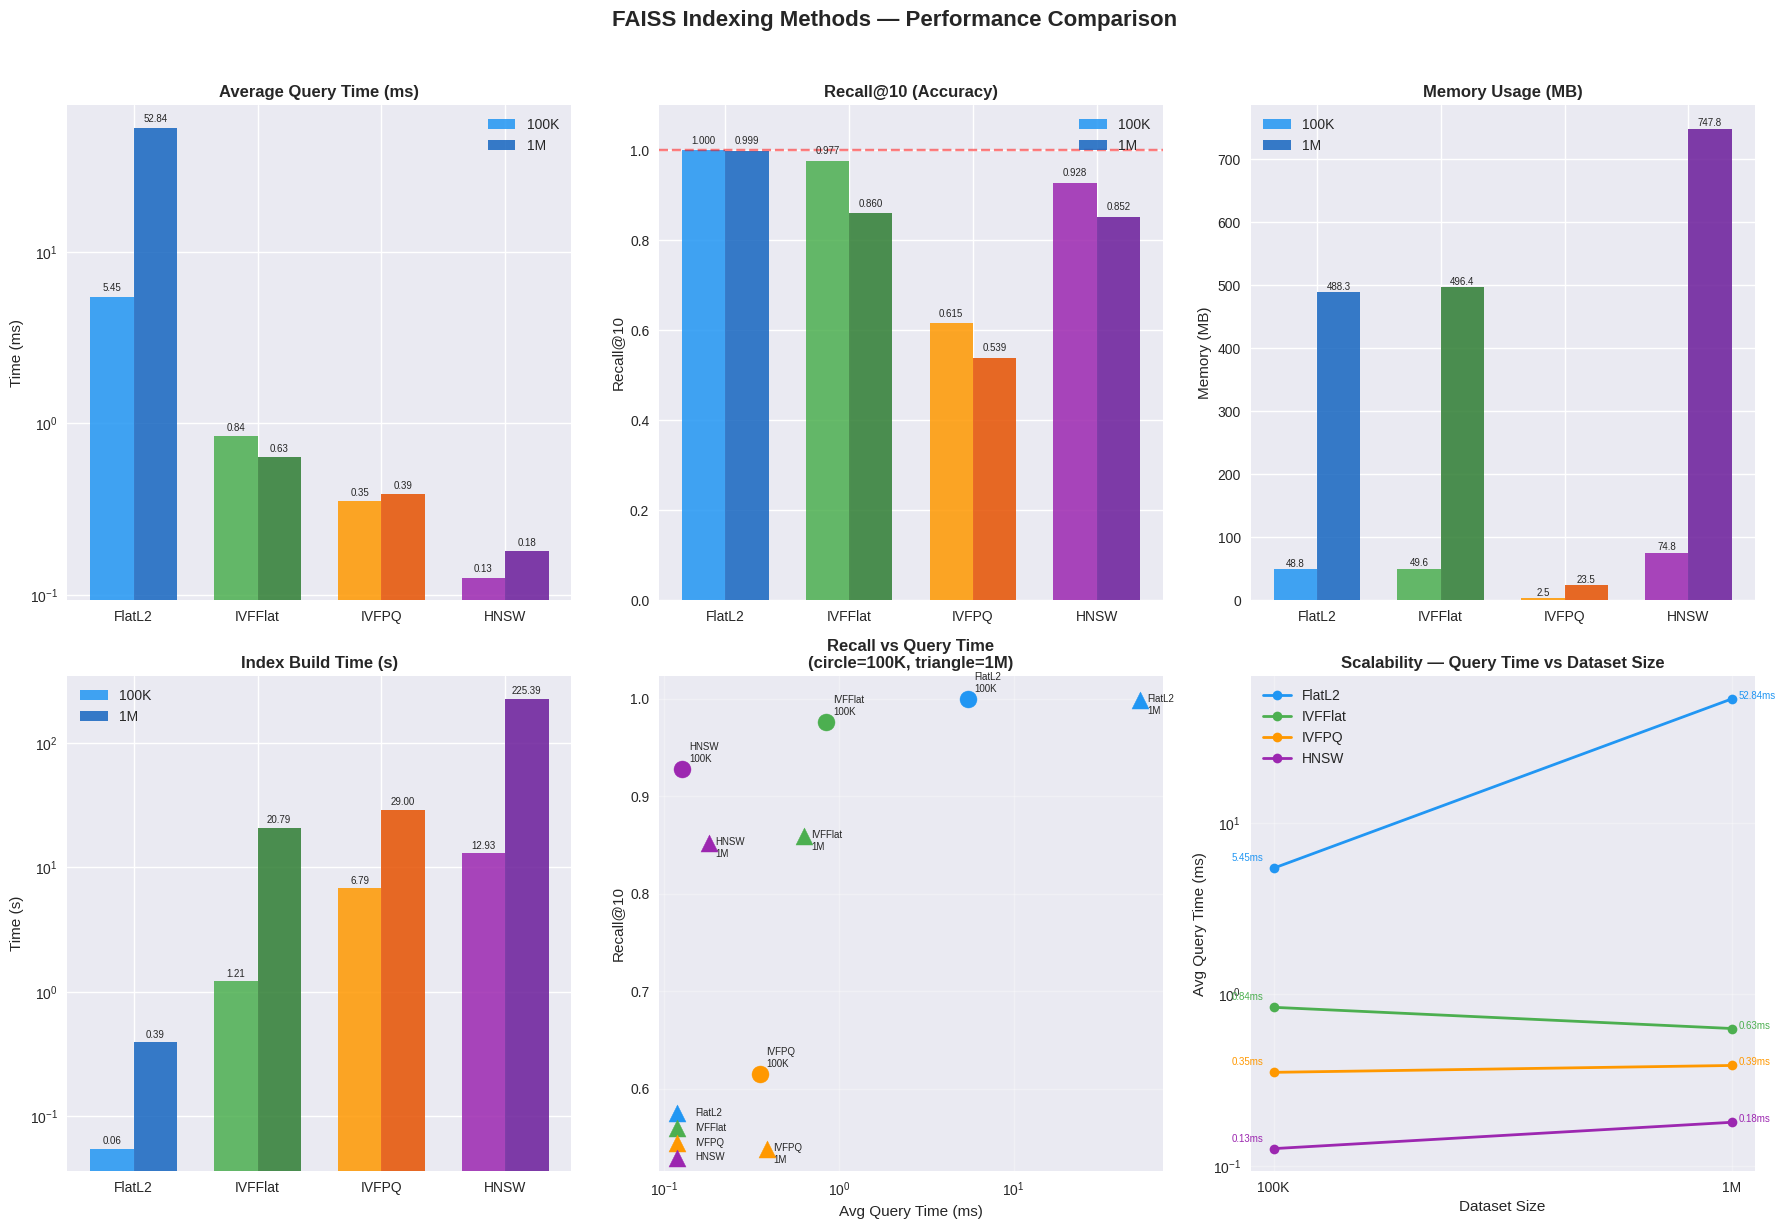

✅ Graphs saved as faiss_comparison.png!


In [ ]:
# Set up the style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('FAISS Indexing Methods — Performance Comparison',
             fontsize=16, fontweight='bold', y=1.02)

colors_100k = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
colors_1m   = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
indexes = ['FlatL2', 'IVFFlat', 'IVFPQ', 'HNSW']
x = np.arange(len(indexes))
width = 0.35

df_100k = df[df['Dataset Size'] == '100K'].reset_index(drop=True)
df_1m   = df[df['Dataset Size'] == '1M'].reset_index(drop=True)

# ── Graph 1: Query Time ──────────────────────────────────────────────
ax1 = axes[0, 0]
bars1 = ax1.bar(x - width/2, df_100k['Avg Query Time (ms)'], width,
                label='100K', color=colors_100k, alpha=0.85)
bars2 = ax1.bar(x + width/2, df_1m['Avg Query Time (ms)'], width,
                label='1M', color=colors_1m, alpha=0.85)
ax1.set_title('Average Query Time (ms)', fontweight='bold')
ax1.set_ylabel('Time (ms)')
ax1.set_xticks(x)
ax1.set_xticklabels(indexes)
ax1.legend()
ax1.set_yscale('log')  # log scale because FlatL2 is much slower
for bar in bars1: ax1.text(bar.get_x()+bar.get_width()/2,
                            bar.get_height()*1.05,
                            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars2: ax1.text(bar.get_x()+bar.get_width()/2,
                            bar.get_height()*1.05,
                            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

# ── Graph 2: Recall@10 ───────────────────────────────────────────────
ax2 = axes[0, 1]
bars3 = ax2.bar(x - width/2, df_100k['Recall@10'], width,
                label='100K', color=colors_100k, alpha=0.85)
bars4 = ax2.bar(x + width/2, df_1m['Recall@10'], width,
                label='1M', color=colors_1m, alpha=0.85)
ax2.set_title('Recall@10 (Accuracy)', fontweight='bold')
ax2.set_ylabel('Recall@10')
ax2.set_ylim(0, 1.1)
ax2.set_xticks(x)
ax2.set_xticklabels(indexes)
ax2.legend()
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect Recall')
for bar in bars3: ax2.text(bar.get_x()+bar.get_width()/2,
                            bar.get_height()+0.01,
                            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in bars4: ax2.text(bar.get_x()+bar.get_width()/2,
                            bar.get_height()+0.01,
                            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

# ── Graph 3: Memory Usage ────────────────────────────────────────────
ax3 = axes[0, 2]
bars5 = ax3.bar(x - width/2, df_100k['Memory (MB)'], width,
                label='100K', color=colors_100k, alpha=0.85)
bars6 = ax3.bar(x + width/2, df_1m['Memory (MB)'], width,
                label='1M', color=colors_1m, alpha=0.85)
ax3.set_title('Memory Usage (MB)', fontweight='bold')
ax3.set_ylabel('Memory (MB)')
ax3.set_xticks(x)
ax3.set_xticklabels(indexes)
ax3.legend()
for bar in bars5: ax3.text(bar.get_x()+bar.get_width()/2,
                            bar.get_height()+1,
                            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
for bar in bars6: ax3.text(bar.get_x()+bar.get_width()/2,
                            bar.get_height()+1,
                            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

# ── Graph 4: Build Time ──────────────────────────────────────────────
ax4 = axes[1, 0]
bars7 = ax4.bar(x - width/2, df_100k['Build Time (s)'], width,
                label='100K', color=colors_100k, alpha=0.85)
bars8 = ax4.bar(x + width/2, df_1m['Build Time (s)'], width,
                label='1M', color=colors_1m, alpha=0.85)
ax4.set_title('Index Build Time (s)', fontweight='bold')
ax4.set_ylabel('Time (s)')
ax4.set_xticks(x)
ax4.set_xticklabels(indexes)
ax4.legend()
ax4.set_yscale('log')
for bar in bars7: ax4.text(bar.get_x()+bar.get_width()/2,
                            bar.get_height()*1.05,
                            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars8: ax4.text(bar.get_x()+bar.get_width()/2,
                            bar.get_height()*1.05,
                            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

# ── Graph 5: Recall vs Query Time (Scatter) ──────────────────────────
ax5 = axes[1, 1]
scatter_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
for i, idx in enumerate(indexes):
    row_100k = df_100k[df_100k['Index'] == idx].iloc[0]
    row_1m   = df_1m[df_1m['Index'] == idx].iloc[0]
    ax5.scatter(row_100k['Avg Query Time (ms)'], row_100k['Recall@10'],
                color=scatter_colors[i], s=150, marker='o', zorder=5)
    ax5.scatter(row_1m['Avg Query Time (ms)'], row_1m['Recall@10'],
                color=scatter_colors[i], s=150, marker='^', zorder=5,
                label=idx)
    ax5.annotate(f'{idx}\n100K', (row_100k['Avg Query Time (ms)'],
                                   row_100k['Recall@10']),
                 textcoords='offset points', xytext=(5, 5), fontsize=7)
    ax5.annotate(f'{idx}\n1M', (row_1m['Avg Query Time (ms)'],
                                 row_1m['Recall@10']),
                 textcoords='offset points', xytext=(5, -10), fontsize=7)
ax5.set_title('Recall vs Query Time\n(circle=100K, triangle=1M)', fontweight='bold')
ax5.set_xlabel('Avg Query Time (ms)')
ax5.set_ylabel('Recall@10')
ax5.set_xscale('log')
ax5.legend(fontsize=7)
ax5.grid(True, alpha=0.3)

# ── Graph 6: Scalability ─────────────────────────────────────────────
ax6 = axes[1, 2]
sizes = ['100K', '1M']
for i, idx in enumerate(indexes):
    times = [df[( df['Index']==idx) & (df['Dataset Size']=='100K')]['Avg Query Time (ms)'].values[0],
             df[(df['Index']==idx) & (df['Dataset Size']=='1M') ]['Avg Query Time (ms)'].values[0]]
    ax6.plot(sizes, times, marker='o', linewidth=2,
             color=scatter_colors[i], label=idx)
    ax6.annotate(f'{times[0]:.2f}ms', (sizes[0], times[0]),
                 textcoords='offset points', xytext=(-30, 5), fontsize=7,
                 color=scatter_colors[i])
    ax6.annotate(f'{times[1]:.2f}ms', (sizes[1], times[1]),
                 textcoords='offset points', xytext=(5, 0), fontsize=7,
                 color=scatter_colors[i])
ax6.set_title('Scalability — Query Time vs Dataset Size', fontweight='bold')
ax6.set_xlabel('Dataset Size')
ax6.set_ylabel('Avg Query Time (ms)')
ax6.set_yscale('log')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('faiss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphs saved as faiss_comparison.png!")

In [ ]:
# Save the results table as CSV
df.to_csv('faiss_results.csv', index=False)
print("✅ Results saved to faiss_results.csv!")
print("\nFinal Summary:")
print(df.to_string(index=False))

✅ Results saved to faiss_results.csv!

Final Summary:
  Index Dataset Size  Build Time (s)  Memory (MB)  Avg Query Time (ms)  Recall@10
 FlatL2         100K           0.055        48.83               5.4462     1.0000
 FlatL2           1M           0.393       488.28              52.8391     0.9991
IVFFlat         100K           1.214        49.64               0.8421     0.9768
IVFFlat           1M          20.790       496.41               0.6335     0.8596
  IVFPQ         100K           6.786         2.46               0.3517     0.6152
  IVFPQ           1M          29.003        23.51               0.3857     0.5386
   HNSW         100K          12.927        74.79               0.1263     0.9284
   HNSW           1M         225.387       747.80               0.1799     0.8523


In [ ]:
print("=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)

df_1m = df[df['Dataset Size'] == '1M'].reset_index(drop=True)
baseline_time = df_1m[df_1m['Index']=='FlatL2']['Avg Query Time (ms)'].values[0]
baseline_mem  = df_1m[df_1m['Index']=='FlatL2']['Memory (MB)'].values[0]

for _, row in df_1m.iterrows():
    speedup = baseline_time / row['Avg Query Time (ms)']
    mem_ratio = baseline_mem / row['Memory (MB)']
    print(f"\n📌 {row['Index']}:")
    print(f"   Speed: {speedup:.1f}x faster than FlatL2")
    print(f"   Memory: {mem_ratio:.1f}x less than FlatL2")
    print(f"   Recall: {row['Recall@10']:.4f}")
    print(f"   Build Time: {row['Build Time (s)']:.2f}s")

KEY FINDINGS SUMMARY

📌 FlatL2:
   Speed: 1.0x faster than FlatL2
   Memory: 1.0x less than FlatL2
   Recall: 0.9991
   Build Time: 0.39s

📌 IVFFlat:
   Speed: 83.4x faster than FlatL2
   Memory: 1.0x less than FlatL2
   Recall: 0.8596
   Build Time: 20.79s

📌 IVFPQ:
   Speed: 137.0x faster than FlatL2
   Memory: 20.8x less than FlatL2
   Recall: 0.5386
   Build Time: 29.00s

📌 HNSW:
   Speed: 293.7x faster than FlatL2
   Memory: 0.7x less than FlatL2
   Recall: 0.8523
   Build Time: 225.39s


In [ ]:
print("=" * 60)
print("CONCLUSIONS")
print("=" * 60)

print("""
1. ACCURACY vs SPEED TRADEOFF:
   FlatL2 achieves perfect recall (0.9991) but is the slowest
   (52.84ms per query on 1M vectors). Approximate indexes
   sacrifice some accuracy for massive speed gains.

2. BEST FOR SPEED → HNSW:
   293.7x faster than FlatL2 with a recall of 0.8523.
   Ideal for real-time applications like recommendation
   systems and AI assistants.

3. BEST FOR MEMORY → IVFPQ:
   Uses only 23.51MB for 1M vectors (20.8x less than FlatL2).
   Ideal when RAM is limited, such as mobile or edge devices.

4. BEST BALANCE → IVFFlat:
   83.4x faster than FlatL2 with recall of 0.8596.
   Good balance between speed, memory and accuracy.

5. SCALABILITY:
   FlatL2 scales poorly — query time grows 10x when data
   grows 10x. HNSW and IVFPQ scale much better, making them
   suitable for production systems with millions of vectors.

6. RECOMMENDATION:
   - Need accuracy? → Use FlatL2 (small datasets only)
   - Need speed? → Use HNSW
   - Need low memory? → Use IVFPQ
   - Need balance? → Use IVFFlat
""")
print("✅ Project Complete!")

CONCLUSIONS

1. ACCURACY vs SPEED TRADEOFF:
   FlatL2 achieves perfect recall (0.9991) but is the slowest
   (52.84ms per query on 1M vectors). Approximate indexes 
   sacrifice some accuracy for massive speed gains.

2. BEST FOR SPEED → HNSW:
   293.7x faster than FlatL2 with a recall of 0.8523.
   Ideal for real-time applications like recommendation 
   systems and AI assistants.

3. BEST FOR MEMORY → IVFPQ:
   Uses only 23.51MB for 1M vectors (20.8x less than FlatL2).
   Ideal when RAM is limited, such as mobile or edge devices.

4. BEST BALANCE → IVFFlat:
   83.4x faster than FlatL2 with recall of 0.8596.
   Good balance between speed, memory and accuracy.

5. SCALABILITY:
   FlatL2 scales poorly — query time grows 10x when data 
   grows 10x. HNSW and IVFPQ scale much better, making them
   suitable for production systems with millions of vectors.

6. RECOMMENDATION:
   - Need accuracy? → Use FlatL2 (small datasets only)
   - Need speed? → Use HNSW
   - Need low memory? → Use IVFP